In [ ]:
### two-stage model combined result analysis

In [11]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import itertools
woking_path = '../'
print(woking_path )
import sys
sys.path.append(curr_pth)
from utils.utilities import compute_spearman_corr,compute_pearson_corr

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
../


In [12]:
#data_name = 'ABE8e-SpCas9'
model_name = 'CNN'
screen_name = ''
in_vivo = True
version=2
num_runs = 3
exp_name = 'protospacer_PAM'



In [13]:
def get_overall_prob(pdf, edf):
    df_new = pdf.copy()
    ID=pdf.iloc[0]['seq_id']
    #print(ID)
    pred_y = edf[edf['id']== ID]['pred_class'].tolist()
    #print(pred_y)
    true_y = edf[edf['id']== ID]['true_class'].tolist()
    #print(true_y)
    x_pred = pdf[pdf['seq_id']==ID]['pred_score']
    x_pred = np.array(x_pred)
    x_true = pdf[pdf['seq_id']==ID]['true_score']
    x_true = np.array(x_true)
    df_new['overall_true'] = x_true*true_y[0]
    df_new['overall_pred'] = x_pred*pred_y[0]
    df_new=df_new.drop(df_new.columns[0], axis=1)
    ## adding back the wild type
    #if ID == 'NM_000520.6(HEXA)c.91CtoT(p.Gln31Ter)Position6':
        #print(pred_y)
    new_row = pd.Series([ID, pdf.iloc[0]['Inp_seq'], pdf.iloc[0]['Inp_seq'], 1, 1 ,1-true_y[0], 1-pred_y[0]], index=df_new.columns)
    df_new.loc[len(df_new)] = new_row
    return df_new

In [14]:
def peformance_report(data_name,saved_model, exp_name,num_runs, in_vivo, screen_type, transfer_learning,model_cell_type, data_cell_type):
    model_name = 'CNN'
    print('result for',exp_name)
    print(transfer_learning)
    if not transfer_learning:   
        if not in_vivo:
            proportion = os.path.join(woking_path , 'proportion_model','output', 'experiment_run_proportions_encenc_two_model', f'{data_name}_proportions_encenc_two_model' ,exp_name,'exp_version_0/test/')
            #proportion = os.path.join(woking_path , 'proportion_model','output', 'experiment_run_DeepBE', f'{data_name}_DeepBE' ,exp_name,'exp_version_0/test/')
            absolute_efficiency = os.path.join(woking_path , 'absolute_efficiency_model', 'output' ,f'{model_name}_v{version}',data_name, exp_name, 'test/')
            #absolute_efficiency = os.path.join(woking_path , 'absolute_efficiency_model', 'output' ,f'{model_name}_v{version}',f'{data_name}_DeepBE', exp_name, 'test/')
            print(proportion)
            print(absolute_efficiency)
        else:
            
            proportion = os.path.join(woking_path , 'proportion_model','output', 'experiment_run_proportions_encenc_two_model',screen_type,  f'{data_name}_proportions_encenc_two_model' ,exp_name,'exp_version_0/test/')
            absolute_efficiency = os.path.join(woking_path , 'absolute_efficiency_model', 'output' ,f'{model_name}_v{version}','invivo',screen_type,  data_name, exp_name, 'test/')
    else:
        
        if model_cell_type is not None:
            print('we are running transfer learning within invivo')
            proportion = os.path.join(woking_path , 'proportion_model','output', 'experiment_run_proportions_encenc_two_model','transfer_learning',f'model_{model_cell_type}_data_{data_cell_type}', data_name ,exp_name,'test/')
            print(proportion)
            absolute_efficiency = os.path.join(woking_path , 'absolute_efficiency_model', 'output' ,f'{model_name}_v{version}','transfer_learning',f'model_{model_cell_type}_data_{data_cell_type}', data_name,exp_name)
            print(absolute_efficiency)
        else:
            if data_name == saved_model:
                print('we are running transfer learning from vitro to vivo')
                proportion = os.path.join(woking_path , 'proportion_model','output', 'experiment_run_proportions_encenc_two_model','transfer_learning','vitro_model_vivo_data',screen_type, data_name ,exp_name,'test')
                print(proportion)
                absolute_efficiency = os.path.join(woking_path , 'absolute_efficiency_model', 'output' ,f'{model_name}_v{version}','transfer_learning','vitro_model_vivo_data', screen_type, data_name, exp_name)
                print(absolute_efficiency)
            else: 
                print('we are running transfer learning within invivo/invitro')
                proportion = os.path.join(woking_path , 'proportion_model','output', 'experiment_run_proportions_encenc_two_model','transfer_learning',f'model_{saved_model}_data_{data_name}',screen_type, data_name ,exp_name,'test/')
                print(proportion)
                absolute_efficiency = os.path.join(woking_path , 'absolute_efficiency_model', 'output' ,f'{model_name}_v{version}','transfer_learning',f'model_{saved_model}_data_{data_name}', screen_type,data_name, exp_name)
                print(absolute_efficiency)


    spearman_overall = []
    pearson_overall = []
    spearman_proportion = []
    pearson_proportion = []
    spearman_proportion_denorm = []
    pearson_proportion_denorm = []
    for i in range(num_runs):
        print('run number:', i)
        proportion_df = pd.read_csv(os.path.join(proportion,'run_'f'{i}', 'predictions_test.csv'), )
        efficiency_df = pd.read_csv(os.path.join(absolute_efficiency,'run_'f'{i}','predictions_test.csv'), )
        #print(len(efficiency_df))
        #print(efficiency_df)
        dfg = proportion_df.groupby('seq_id')
        final_df = dfg.apply(get_overall_prob,efficiency_df )
        final_df.reset_index(inplace=True, drop=True)
        non_wild_df = final_df.copy()
        non_wild_df = non_wild_df.drop(non_wild_df[non_wild_df['Inp_seq'] == non_wild_df['Outp_seq']].index)
        
        wild_df = final_df.copy()
        wild_df = wild_df[wild_df['Inp_seq'] == wild_df['Outp_seq']]
        
        spearman_corr, pvalue_spc = compute_spearman_corr(final_df['overall_pred'], final_df['overall_true'])
        pearson_corr, pvalue_prc = compute_pearson_corr(final_df['overall_pred'], final_df['overall_true'])
        spearman_overall.append(spearman_corr)
        pearson_overall.append(pearson_corr)
        
        spearman_proportion.append(compute_spearman_corr(proportion_df['pred_score'], proportion_df['true_score'])[0])
        pearson_proportion.append(compute_pearson_corr(proportion_df['pred_score'], proportion_df['true_score'])[0])
        
        
        spearman_proportion_denorm.append(compute_spearman_corr(non_wild_df['overall_pred'], non_wild_df['overall_true'])[0])
        pearson_proportion_denorm.append(compute_pearson_corr(non_wild_df['overall_pred'], non_wild_df['overall_true'])[0])
        
    spearman_overall.append(np.array(spearman_overall).mean(axis = 0))
    pearson_overall.append(np.array(pearson_overall).mean(axis = 0))
    spearman_overall.append(np.array(spearman_overall).std(axis = 0))
    pearson_overall.append(np.array(pearson_overall).std(axis = 0))
    print('for over all model',exp_name,data_name  )
    print('spearman correlation',spearman_overall)
    print('pearson correlation',pearson_overall)
    print('')
    
   
    spearman_proportion.append(np.array(spearman_proportion).mean(axis = 0))
    pearson_proportion.append(np.array(pearson_proportion).mean(axis = 0))
    spearman_proportion.append(np.array(spearman_proportion).std(axis = 0))
    pearson_proportion.append(np.array(pearson_proportion).std(axis = 0))
    print('proportion model on the renormalized space',exp_name,data_name  )
    print('spearman correlation',spearman_proportion)
    print('pearson correlation',pearson_proportion)
    print('')
    
    
    spearman_proportion_denorm.append(np.array(spearman_proportion_denorm).mean(axis = 0))
    pearson_proportion_denorm.append(np.array(pearson_proportion_denorm).mean(axis = 0))
    spearman_proportion_denorm.append(np.array(spearman_proportion_denorm).std(axis = 0))
    pearson_proportion_denorm.append(np.array(pearson_proportion_denorm).std(axis = 0))
    print('proportion model on the original space',exp_name,data_name  )
    print('spearman correlation',spearman_proportion_denorm)
    print('pearson correlation',pearson_proportion_denorm)
    print('')
    
    
    return final_df, proportion_df,efficiency_df, non_wild_df, wild_df

In [15]:
#if in vitro
in_vivo = False
transfer_learning = False
screen_name = ''
model_cell_type = ''
data_cell_type = ''
data_name = 'ABEmax-SpRY'
model_name ='ABEmax-SpRY'

final_df, proportion_df,efficiency_df,non_wild_df, wild_df = peformance_report(data_name, data_name, 'protospacer_PAM',num_runs, in_vivo,screen_name,transfer_learning, model_cell_type, data_cell_type)



result for protospacer_PAM
False
../proportion_model/output/experiment_run_proportions_encenc_two_model/ABEmax-SpRY_proportions_encenc_two_model/protospacer_PAM/exp_version_0/test/
../absolute_efficiency_model/output/CNN_v2/ABEmax-SpRY/protospacer_PAM/test/
run number: 0
run number: 1
run number: 2
for over all model protospacer_PAM ABEmax-SpRY
spearman correlation [0.6632619540317911, 0.8873585562010277, 0.8830773967857395, 0.8112326356728529, 0.090625807721849]
pearson correlation [0.9718422704169107, 0.9908489307409488, 0.9912459813154623, 0.9846457274911073, 0.007841740784984397]

proportion model on the renormalized space protospacer_PAM ABEmax-SpRY
spearman correlation [0.5332300879212339, 0.878485964825685, 0.8796589316645068, 0.7637916614704753, 0.14119016141524857]
pearson correlation [0.5758365782417731, 0.9326619726369656, 0.9357366199809497, 0.8147450569532295, 0.14630500549236047]

proportion model on the original space protospacer_PAM ABEmax-SpRY
spearman correlation [0.4

In [86]:
data_name == model_name

True

In [16]:
##if in vivo:
#in_vivo = False
transfer_learning = True
screen_name = 'Liver_SBApproach'
#model_cell_type = 'Liver_LentiAAV'
#data_cell_type = 'Liver_LentiAAV'
data_name = 'ABEmax-SPRY'
model_name ='ABEmax-SPRY'
model_cell_type = ''
data_cell_type = 'Liver_SBApproach'
#final_df, proportion_df,efficiency_df,non_wild_df, wild_df = peformance_report(data_name,model_name, 'protospacer_PAM',num_runs, in_vivo, '', transfer_learning, model_cell_type, data_cell_type)


if in_vivo:
    if screen_name == 'Liver_LentiAAV':
        for data_name in ['ABEmax-SpRY', 'ABE8e-SpRY']:
            peformance_report(data_name, data_name, 'protospacer_PAM',num_runs, True,screen_name,transfer_learning, model_cell_type, data_cell_type)

    if screen_name == 'Liver_LentiLNP':
        for data_name in ['ABEmax-SpRY','ABE8e-NG', 'ABE8e-SpRY','ABE8e-SpCas9' ]:
            peformance_report(data_name, data_name,'protospacer_PAM',num_runs, True,screen_name,transfer_learning,model_cell_type, data_cell_type)


    if screen_name == 'Liver_SBApproach':
        for data_name in ['ABEmax-SpRY' ]:
            peformance_report(data_name,data_name, 'protospacer_PAM',num_runs, True,screen_name,transfer_learning,model_cell_type, data_cell_type)

        
else:
    
    for data_name in ['ABEmax-SpRY','ABEmax-SpCas9','ABEmax-NG',  'ABE8e-SpRY','ABE8e-SpCas9','ABE8e-NG' ]:
        peformance_report(data_name,model_name, 'protospacer_PAM',num_runs, False, '', False,model_cell_type, data_cell_type)
 


result for protospacer_PAM
False
../proportion_model/output/experiment_run_proportions_encenc_two_model/ABEmax-SpRY_proportions_encenc_two_model/protospacer_PAM/exp_version_0/test/
../absolute_efficiency_model/output/CNN_v2/ABEmax-SpRY/protospacer_PAM/test/
run number: 0
run number: 1
run number: 2
for over all model protospacer_PAM ABEmax-SpRY
spearman correlation [0.6632619540317911, 0.8873585562010277, 0.8830773967857395, 0.8112326356728529, 0.090625807721849]
pearson correlation [0.9718422704169107, 0.9908489307409488, 0.9912459813154623, 0.9846457274911073, 0.007841740784984397]

proportion model on the renormalized space protospacer_PAM ABEmax-SpRY
spearman correlation [0.5332300879212339, 0.878485964825685, 0.8796589316645068, 0.7637916614704753, 0.14119016141524857]
pearson correlation [0.5758365782417731, 0.9326619726369656, 0.9357366199809497, 0.8147450569532295, 0.14630500549236047]

proportion model on the original space protospacer_PAM ABEmax-SpRY
spearman correlation [0.4

### scatter plot

In [17]:
in_vivo = True
transfer_learning = False
data_name = 'ABE8e-SpRY'
model_name ='ABE8e-SpRY'
screen_name = 'Liver_SBApproach'
model_cell_type = ''
data_cell_type = ''
final_df, proportion_df,efficiency_df, non_wild_df, wild_df = peformance_report(data_name, model_name, 'protospacer_PAM',num_runs, True,screen_name,transfer_learning, model_cell_type, data_cell_type)

result for protospacer_PAM
False
run number: 0
run number: 1
run number: 2
for over all model protospacer_PAM ABE8e-SpRY
spearman correlation [0.8624631094841574, 0.8678076771831651, 0.8760556329743311, 0.8687754732138845, 0.004842088680287578]
pearson correlation [0.98414228583125, 0.9839116439172294, 0.983592913097618, 0.983882280948699, 0.00019506311549758953]

proportion model on the renormalized space protospacer_PAM ABE8e-SpRY
spearman correlation [0.8568768143445067, 0.8650910533202459, 0.8673891951588655, 0.863119020941206, 0.003907954795958561]
pearson correlation [0.9180582193453257, 0.9223279944987111, 0.914983386122742, 0.9184565333222596, 0.002608141921680489]

proportion model on the original space protospacer_PAM ABE8e-SpRY
spearman correlation [0.780621109464379, 0.7862785476839788, 0.7948412683188578, 0.7872469751557385, 0.005062441026209454]
pearson correlation [0.791615166367878, 0.7765074599864973, 0.7848147329388949, 0.7843124530977567, 0.005350229518703528]




### Analysis and plots

In [18]:
def scatter_plot(df, pred, true, data_name, over_all, in_vivo ,screen_name):
    spearman_corr, pvalue_spc = compute_spearman_corr(df[true], df[pred])
    pearson_corr, pvalue_prc = compute_pearson_corr(df[true], df[pred])
    print('spearmand correlation:', spearman_corr)
    print('pearson correlation:', pearson_corr)

    plt.scatter(df[true],df[pred],s=2, color='black')
    # Add a line representing the correlation
    #m, b = np.polyfit(df[true], df[pred], deg=1)
    #plt.axline(xy1=(0, b), slope=m, color='grey',label=f'Pearson correlation {round(spearman_corr,3)}')
    #plt.xlim(0, 1)
    #plt.ylim(0, 1)
    m, b = np.polyfit(df[true], df[pred], deg=1)
    
    # Clip the line so it doesn't go below zero on the y-axis
    x_values = np.array(plt.xlim())
    y_values = m * x_values + b
    y_values = np.maximum(y_values, 0)
    x_values = np.maximum(x_values, 0)
    #y_values = np.clip(y_values, 0, None)  # Clip to zero or positive values
    
    plt.plot(x_values, y_values, color='grey', label=f'Pearson correlation {round(spearman_corr, 3)}')
    custom_legend = [plt.Line2D([], [], color='grey', linestyle='-', label=f'Pearson correlation {round(pearson_corr,3)}'),
                     plt.Line2D([], [], color='grey', linestyle='', label=f'Spearman correlation {round(spearman_corr,3)}')]
    
    plt.legend(handles=custom_legend, loc="lower right")
    #legend.texts[0].set_text(f'Spearman correlation {round(pearson_corr,3)}')
    plt.title(f'{data_name} Testset (on {over_all} type)')
    plt.xlabel('True probability')
    plt.ylabel('Predicted probability')
    #plt.xlim(0, max(df[true].max(), df[pred].max())+0.05 )
    #plt.ylim(0, max(df[true].max(), df[pred].max())+0.05 )
    if in_vivo:
        folder_name = f'./in_vivo/{screen_name}'
        if not os.path.exists(folder_name):
            os.mkdir(folder_name)
        plt.savefig(f'{folder_name}/scatter_plot_{data_name}_{over_all}.svg')
    else: 
        plt.savefig(f'./in_vitro/scatter_plot_{data_name}_{over_all}.svg')

In [19]:
final_df

,seq_id,Inp_seq,Outp_seq,true_score,pred_score,overall_true,overall_pred
0,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position10,ACATGCTTGACGCCATATTTCAAT,ACGTGCTTGACGCCATATTTCAAT,1.000000,1.000000,0.004306,0.066013
1,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position10,ACATGCTTGACGCCATATTTCAAT,ACATGCTTGACGCCATATTTCAAT,1.000000,1.000000,0.995694,0.933987
2,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position11,CACATGCTTGACGCCATATTTCAA,CACGTGCTTGACGCCATATTTCAA,1.000000,1.000000,0.018182,0.043990
3,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position11,CACATGCTTGACGCCATATTTCAA,CACATGCTTGACGCCATATTTCAA,1.000000,1.000000,0.981818,0.956010
4,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position8,ATGCTTGACGCCATATTTCAATGT,ATGCTTGGCGCCATATTTCAATGT,0.995169,0.972789,0.143654,0.009058
...,...,...,...,...,...,...,...
6857,NM_198903.2(GABRG2)c.406CtoT(p.Arg136Ter)Posit...,TTCAATCAGAGGACTTTAATGGTG,TTCGATCAGAGGACTTTAATGGTG,0.087349,0.150681,0.037227,0.012147
6858,NM_198903.2(GABRG2)c.406CtoT(p.Arg136Ter)Posit...,TTCAATCAGAGGACTTTAATGGTG,TTCAGTCAGAGGACTTTAATGGTG,0.006024,0.010442,0.002567,0.000842
6859,NM_198903.2(GABRG2)c.406CtoT(p.Arg136Ter)Posit...,TTCAATCAGAGGACTTTAATGGTG,TTCAGTCGGAGGACTTTAATGGTG,0.063253,0.020511,0.026958,0.001653
6860,NM_198903.2(GABRG2)c.406CtoT(p.Arg136Ter)Posit...,TTCAATCAGAGGACTTTAATGGTG,TTCAATCAGGGGACTTTAATGGTG,0.006024,0.002672,0.002567,0.000215


In [20]:
final_df

,seq_id,Inp_seq,Outp_seq,true_score,pred_score,overall_true,overall_pred
0,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position10,ACATGCTTGACGCCATATTTCAAT,ACGTGCTTGACGCCATATTTCAAT,1.000000,1.000000,0.004306,0.066013
1,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position10,ACATGCTTGACGCCATATTTCAAT,ACATGCTTGACGCCATATTTCAAT,1.000000,1.000000,0.995694,0.933987
2,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position11,CACATGCTTGACGCCATATTTCAA,CACGTGCTTGACGCCATATTTCAA,1.000000,1.000000,0.018182,0.043990
3,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position11,CACATGCTTGACGCCATATTTCAA,CACATGCTTGACGCCATATTTCAA,1.000000,1.000000,0.981818,0.956010
4,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position8,ATGCTTGACGCCATATTTCAATGT,ATGCTTGGCGCCATATTTCAATGT,0.995169,0.972789,0.143654,0.009058
...,...,...,...,...,...,...,...
6857,NM_198903.2(GABRG2)c.406CtoT(p.Arg136Ter)Posit...,TTCAATCAGAGGACTTTAATGGTG,TTCGATCAGAGGACTTTAATGGTG,0.087349,0.150681,0.037227,0.012147
6858,NM_198903.2(GABRG2)c.406CtoT(p.Arg136Ter)Posit...,TTCAATCAGAGGACTTTAATGGTG,TTCAGTCAGAGGACTTTAATGGTG,0.006024,0.010442,0.002567,0.000842
6859,NM_198903.2(GABRG2)c.406CtoT(p.Arg136Ter)Posit...,TTCAATCAGAGGACTTTAATGGTG,TTCAGTCGGAGGACTTTAATGGTG,0.063253,0.020511,0.026958,0.001653
6860,NM_198903.2(GABRG2)c.406CtoT(p.Arg136Ter)Posit...,TTCAATCAGAGGACTTTAATGGTG,TTCAATCAGGGGACTTTAATGGTG,0.006024,0.002672,0.002567,0.000215


spearmand correlation: 0.8760556329743311
pearson correlation: 0.983592913097618


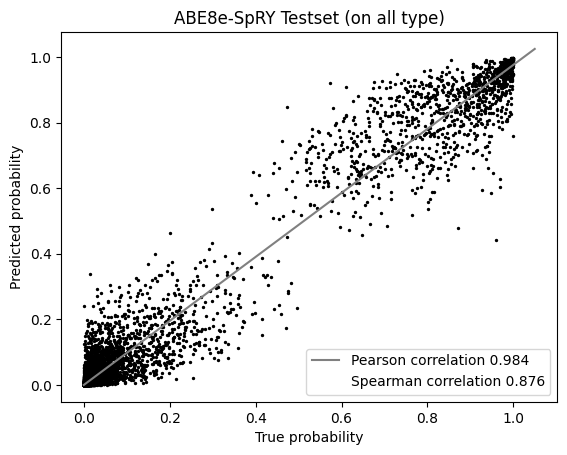

In [21]:
scatter_plot(final_df, 'overall_pred', 'overall_true', data_name, 'all', True,screen_name)


In [22]:
final_df[final_df['Inp_seq']=='CACATGCTTGACGCCATATTTCAA']

,seq_id,Inp_seq,Outp_seq,true_score,pred_score,overall_true,overall_pred
2,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position11,CACATGCTTGACGCCATATTTCAA,CACGTGCTTGACGCCATATTTCAA,1.0,1.0,0.018182,0.04399
3,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position11,CACATGCTTGACGCCATATTTCAA,CACATGCTTGACGCCATATTTCAA,1.0,1.0,0.981818,0.95601


In [23]:
final_df

,seq_id,Inp_seq,Outp_seq,true_score,pred_score,overall_true,overall_pred
0,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position10,ACATGCTTGACGCCATATTTCAAT,ACGTGCTTGACGCCATATTTCAAT,1.000000,1.000000,0.004306,0.066013
1,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position10,ACATGCTTGACGCCATATTTCAAT,ACATGCTTGACGCCATATTTCAAT,1.000000,1.000000,0.995694,0.933987
2,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position11,CACATGCTTGACGCCATATTTCAA,CACGTGCTTGACGCCATATTTCAA,1.000000,1.000000,0.018182,0.043990
3,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position11,CACATGCTTGACGCCATATTTCAA,CACATGCTTGACGCCATATTTCAA,1.000000,1.000000,0.981818,0.956010
4,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position8,ATGCTTGACGCCATATTTCAATGT,ATGCTTGGCGCCATATTTCAATGT,0.995169,0.972789,0.143654,0.009058
...,...,...,...,...,...,...,...
6857,NM_198903.2(GABRG2)c.406CtoT(p.Arg136Ter)Posit...,TTCAATCAGAGGACTTTAATGGTG,TTCGATCAGAGGACTTTAATGGTG,0.087349,0.150681,0.037227,0.012147
6858,NM_198903.2(GABRG2)c.406CtoT(p.Arg136Ter)Posit...,TTCAATCAGAGGACTTTAATGGTG,TTCAGTCAGAGGACTTTAATGGTG,0.006024,0.010442,0.002567,0.000842
6859,NM_198903.2(GABRG2)c.406CtoT(p.Arg136Ter)Posit...,TTCAATCAGAGGACTTTAATGGTG,TTCAGTCGGAGGACTTTAATGGTG,0.063253,0.020511,0.026958,0.001653
6860,NM_198903.2(GABRG2)c.406CtoT(p.Arg136Ter)Posit...,TTCAATCAGAGGACTTTAATGGTG,TTCAATCAGGGGACTTTAATGGTG,0.006024,0.002672,0.002567,0.000215


spearmand correlation: 0.7533123665846319
pearson correlation: 0.7229354108885887


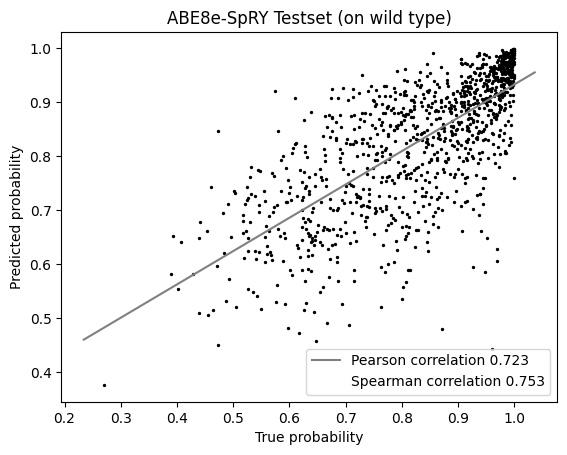

In [24]:
efficiency_df['true_class']= 1-efficiency_df['true_class']
efficiency_df['pred_class']= 1-efficiency_df['pred_class']
scatter_plot(efficiency_df, 'pred_class', 'true_class', data_name, 'wild', in_vivo, screen_name)

In [25]:
efficiency_df

,Unnamed: 0,id,true_class,pred_class
0,0,NM_000053.4(ATP7B)c.3243+1GtoAPosition6,0.963187,0.803932
1,1,NM_000277.3(PAH)c.442-1GtoAPosition4,0.983108,0.972564
2,2,NM_001083962.2(TCF4)c.1570CtoT(p.Gln524Ter)Pos...,0.939036,0.953667
3,3,NM_000334.4(SCN4A)c.4342CtoT(p.Arg1448Cys)Posi...,0.470643,0.596557
4,4,NM_152296.5(ATP1A3)c.2839GtoA(p.Gly947Arg)Posi...,0.934062,0.903373
...,...,...,...,...
1071,1071,NM_015166.3(MLC1)c.67CtoT(p.Gln23Ter)Position7,0.473234,0.450235
1072,1072,NM_001368809.2(AMPD2)c.1859GtoA(p.Arg620His)Po...,0.763130,0.818478
1073,1073,NM_001904.4(CTNNB1)c.1588CtoT(p.Gln530Ter)Posi...,0.793132,0.789121
1074,1074,NM_003560.4(PLA2G6)c.1903CtoT(p.Arg635Ter)Posi...,0.995131,0.964148


In [26]:
wild_df

,seq_id,Inp_seq,Outp_seq,true_score,pred_score,overall_true,overall_pred
1,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position10,ACATGCTTGACGCCATATTTCAAT,ACATGCTTGACGCCATATTTCAAT,1.0,1.0,0.995694,0.933987
3,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position11,CACATGCTTGACGCCATATTTCAA,CACATGCTTGACGCCATATTTCAA,1.0,1.0,0.981818,0.956010
6,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position8,ATGCTTGACGCCATATTTCAATGT,ATGCTTGACGCCATATTTCAATGT,1.0,1.0,0.855649,0.990689
10,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position9,CATGCTTGACGCCATATTTCAATG,CATGCTTGACGCCATATTTCAATG,1.0,1.0,0.971714,0.967882
17,NM_000021.4(PSEN1)c.409GtoA(p.Ala137Thr)Position4,GCTACCATCATGATCAGTGTCATT,GCTACCATCATGATCAGTGTCATT,1.0,1.0,0.851938,0.889696
...,...,...,...,...,...,...,...
6822,NM_198903.2(GABRG2)c.245GtoA(p.Arg82Gln)Position3,TCAGCCTGATATAGGAGGTTTGTT,TCAGCCTGATATAGGAGGTTTGTT,1.0,1.0,0.990272,0.935535
6833,NM_198903.2(GABRG2)c.245GtoA(p.Arg82Gln)Position9,TAAACTTCAGCCTGATATAGGAGG,TAAACTTCAGCCTGATATAGGAGG,1.0,1.0,0.905769,0.897674
6839,NM_198903.2(GABRG2)c.406CtoT(p.Arg136Ter)Posit...,ATCAGAGGACTTTAATGGTGCTGT,ATCAGAGGACTTTAATGGTGCTGT,1.0,1.0,0.796474,0.914898
6847,NM_198903.2(GABRG2)c.406CtoT(p.Arg136Ter)Posit...,AATCAGAGGACTTTAATGGTGCTG,AATCAGAGGACTTTAATGGTGCTG,1.0,1.0,0.663443,0.801142


spearmand correlation: 0.7533123665846319
pearson correlation: 0.7229354108885886


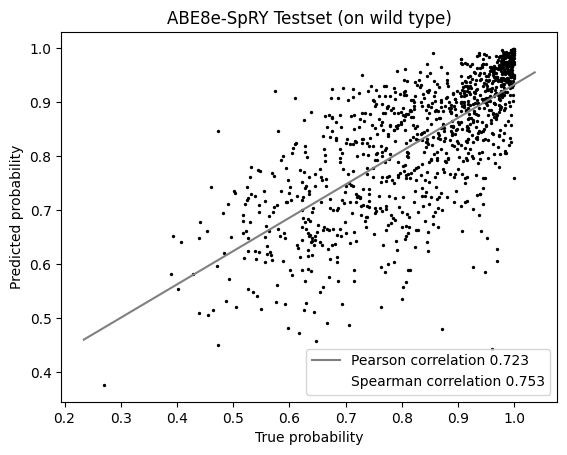

In [27]:
scatter_plot(wild_df, 'overall_pred', 'overall_true', data_name, 'wild', in_vivo, screen_name)

spearmand correlation: 0.7948412683188577
pearson correlation: 0.7848147329388949


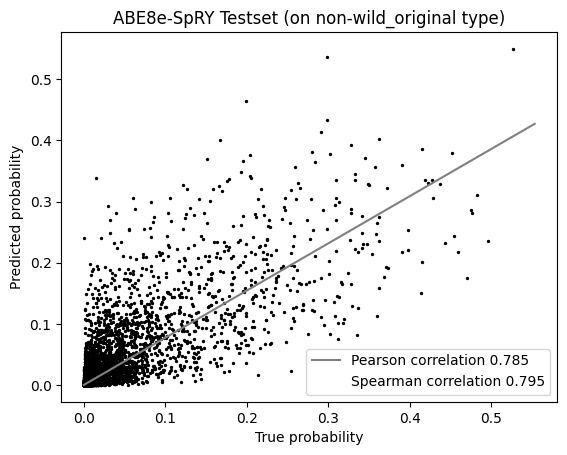

In [28]:
scatter_plot(non_wild_df, 'overall_pred', 'overall_true', data_name, 'non-wild_original',in_vivo, screen_name)

In [29]:
non_wild_df

,seq_id,Inp_seq,Outp_seq,true_score,pred_score,overall_true,overall_pred
0,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position10,ACATGCTTGACGCCATATTTCAAT,ACGTGCTTGACGCCATATTTCAAT,1.000000,1.000000,0.004306,0.066013
2,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position11,CACATGCTTGACGCCATATTTCAA,CACGTGCTTGACGCCATATTTCAA,1.000000,1.000000,0.018182,0.043990
4,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position8,ATGCTTGACGCCATATTTCAATGT,ATGCTTGGCGCCATATTTCAATGT,0.995169,0.972789,0.143654,0.009058
5,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position8,ATGCTTGACGCCATATTTCAATGT,ATGCTTGGCGCCATGTTTCAATGT,0.004831,0.027211,0.000697,0.000253
7,NM_000021.4(PSEN1)c.236CtoT(p.Ala79Val)Position9,CATGCTTGACGCCATATTTCAATG,CATGCTTGGCGCCATATTTCAATG,0.558824,0.245504,0.015807,0.007885
...,...,...,...,...,...,...,...
6856,NM_198903.2(GABRG2)c.406CtoT(p.Arg136Ter)Posit...,TTCAATCAGAGGACTTTAATGGTG,TTCGGTCGGAGGGCTTTAATGGTG,0.003012,0.002951,0.001284,0.000238
6857,NM_198903.2(GABRG2)c.406CtoT(p.Arg136Ter)Posit...,TTCAATCAGAGGACTTTAATGGTG,TTCGATCAGAGGACTTTAATGGTG,0.087349,0.150681,0.037227,0.012147
6858,NM_198903.2(GABRG2)c.406CtoT(p.Arg136Ter)Posit...,TTCAATCAGAGGACTTTAATGGTG,TTCAGTCAGAGGACTTTAATGGTG,0.006024,0.010442,0.002567,0.000842
6859,NM_198903.2(GABRG2)c.406CtoT(p.Arg136Ter)Posit...,TTCAATCAGAGGACTTTAATGGTG,TTCAGTCGGAGGACTTTAATGGTG,0.063253,0.020511,0.026958,0.001653


In [30]:
proportion_df

,Unnamed: 0,seq_id,Inp_seq,Outp_seq,true_score,pred_score
0,0,NM_000053.4(ATP7B)c.3243+1GtoAPosition6,AAGAGATACGTGGACTTGGGCGTG,AGGGGGTGCGTGGACTTGGGCGTG,0.054795,0.021176
1,1,NM_000053.4(ATP7B)c.3243+1GtoAPosition6,AAGAGATACGTGGACTTGGGCGTG,AAGGGATGCGTGGACTTGGGCGTG,0.150685,0.135657
2,2,NM_000053.4(ATP7B)c.3243+1GtoAPosition6,AAGAGATACGTGGACTTGGGCGTG,AAGGGGTGCGTGGACTTGGGCGTG,0.465753,0.459477
3,3,NM_000053.4(ATP7B)c.3243+1GtoAPosition6,AAGAGATACGTGGACTTGGGCGTG,AAGGGATACGTGGACTTGGGCGTG,0.068493,0.053736
4,4,NM_000053.4(ATP7B)c.3243+1GtoAPosition6,AAGAGATACGTGGACTTGGGCGTG,AAGAGGTGCGTGGACTTGGGCGTG,0.068493,0.105486
...,...,...,...,...,...,...
5782,5782,NM_001029896.2(WDR45)c.634CtoT(p.Gln212Ter)Pos...,GGTACCCTTCTAGGAGGCTGAGGC,GGTACCCTTCTGGGGGGCTGAGGC,0.000988,0.000009
5783,5783,NM_001029896.2(WDR45)c.634CtoT(p.Gln212Ter)Pos...,GGTACCCTTCTAGGAGGCTGAGGC,GGTGCCCTTCTGGGAGGCTGAGGC,0.017787,0.011382
5784,5784,NM_001029896.2(WDR45)c.634CtoT(p.Gln212Ter)Pos...,GGTACCCTTCTAGGAGGCTGAGGC,GGTGCCCTTCTAGGAGGCTGAGGC,0.978261,0.985811
5785,5785,NM_001029896.2(WDR45)c.634CtoT(p.Gln212Ter)Pos...,GGTACCCTTCTAGGAGGCTGAGGC,GGTACCCTTCTGGGAGGCTGAGGC,0.000988,0.000690


In [101]:
proportion_df[proportion_df['Inp_seq']=='CTCAAAGGTGAGTTCCTAAGGAGA']

,Unnamed: 0,seq_id,Inp_seq,Outp_seq,true_score,pred_score


spearmand correlation: 0.8673891951588655
pearson correlation: 0.914983386122742


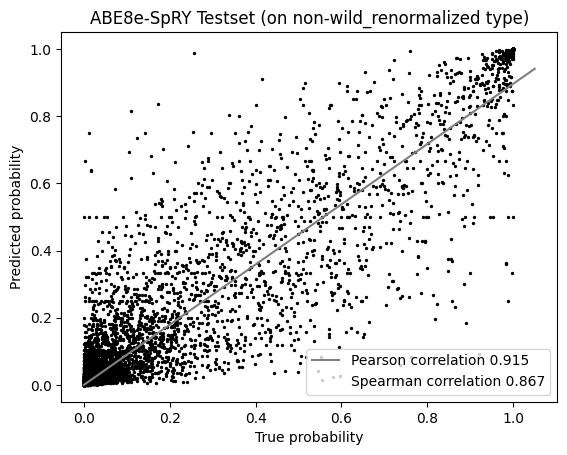

In [102]:
scatter_plot(proportion_df, 'true_score', 'pred_score', data_name, 'non-wild_renormalized',in_vivo, screen_name)